In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW # Changed import to torch.optim
from sklearn.model_selection import train_test_split
import numpy as np


MODEL_NAME = 'bert-base-uncased'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 2e-5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


df = pd.read_csv('Laptop_Train_v2.csv')

label_map = {'negative': 0, 'neutral': 1, 'positive': 2, 'conflict': 3}
df['label'] = df['polarity'].map(label_map)

df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

class ABSADataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['Sentence'].tolist()
        self.aspects = dataframe['Aspect Term'].tolist()
        self.labels = dataframe['label'].tolist()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sentence = str(self.text[index])
        aspect = str(self.aspects[index])
        label = self.labels[index]

        encoding = self.tokenizer(
            sentence,
            aspect,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = ABSADataset(train_df, tokenizer, MAX_LEN)
val_dataset = ABSADataset(val_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)
model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)




Train size: 1886
Validation size: 236
Test size: 236


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
import copy

def train_epoch(model, data_loader, optimizer, device, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)

history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

print("Starting Training...")
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}
best_val_loss = float('inf')
best_model_weights = None
for epoch in range(EPOCHS):
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, DEVICE, len(train_df))
    val_acc, val_loss = eval_model(model, val_loader, DEVICE, len(val_df))

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f'Train loss: {train_loss:.4f} | accuracy: {train_acc:.4f}')
    print(f'Val   loss: {val_loss:.4f} | accuracy: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f">>> Validation Loss improved to {best_val_loss:.4f}. Saving weights...")
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_bert_absa_model.pth')

    print('-' * 20)

print("Training completed. Loading best model weights for testing phase...")
model.load_state_dict(best_model_weights)

Starting Training...
Epoch 1/10
Train loss: 0.9219 | accuracy: 0.6209
Val   loss: 0.7450 | accuracy: 0.7415
>>> Validation Loss improved to 0.7450. Saving weights...
--------------------
Epoch 2/10
Train loss: 0.5973 | accuracy: 0.7964
Val   loss: 0.6388 | accuracy: 0.7669
>>> Validation Loss improved to 0.6388. Saving weights...
--------------------
Epoch 3/10
Train loss: 0.4280 | accuracy: 0.8515
Val   loss: 0.5826 | accuracy: 0.8008
>>> Validation Loss improved to 0.5826. Saving weights...
--------------------
Epoch 4/10
Train loss: 0.3064 | accuracy: 0.8950
Val   loss: 0.6991 | accuracy: 0.7924
--------------------
Epoch 5/10
Train loss: 0.2172 | accuracy: 0.9247
Val   loss: 0.6536 | accuracy: 0.7966
--------------------
Epoch 6/10
Train loss: 0.1683 | accuracy: 0.9417
Val   loss: 0.7132 | accuracy: 0.7881
--------------------
Epoch 7/10
Train loss: 0.1134 | accuracy: 0.9634
Val   loss: 0.7591 | accuracy: 0.7881
--------------------
Epoch 8/10
Train loss: 0.0832 | accuracy: 0.9730


<All keys matched successfully>

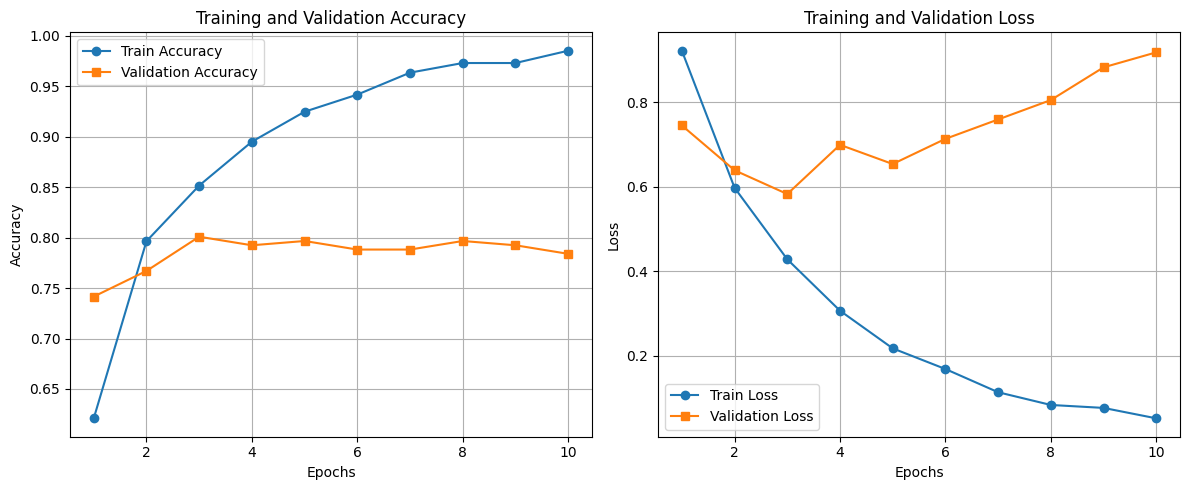

In [4]:
import matplotlib.pyplot as plt

train_acc_list = [acc.item() if torch.is_tensor(acc) else acc for acc in history['train_acc']]
val_acc_list = [acc.item() if torch.is_tensor(acc) else acc for acc in history['val_acc']]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_list, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
test_df.head()

,id,Sentence,Aspect Term,polarity,from,to,label
1647,2922,I have been very pleased with the performance ...,performance,positive,34,45,2
1389,2830,Now when I order I did not go full scale for t...,webcam,neutral,49,55,1
1964,2084,"If you want a little more custom ability, drop...",2GB stick of memory,positive,126,145,2
1014,1138,"Ever since I bought this laptop, so far I've e...",toshiba customer services,negative,160,185,0
2187,1182,"They don t translate from a Mac, even on Word,...",Word,negative,41,45,0


Total test samples after merging: 236

[Phase 3 - A] Classification Report (including Macro-F1):
              precision    recall  f1-score   support

    negative       0.79      0.84      0.81        96
     neutral       0.57      0.51      0.54        47
    positive       0.77      0.80      0.79        87
    conflict       0.00      0.00      0.00         6

    accuracy                           0.74       236
   macro avg       0.53      0.54      0.53       236
weighted avg       0.72      0.74      0.73       236


[Phase 3 - B] Plotting Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


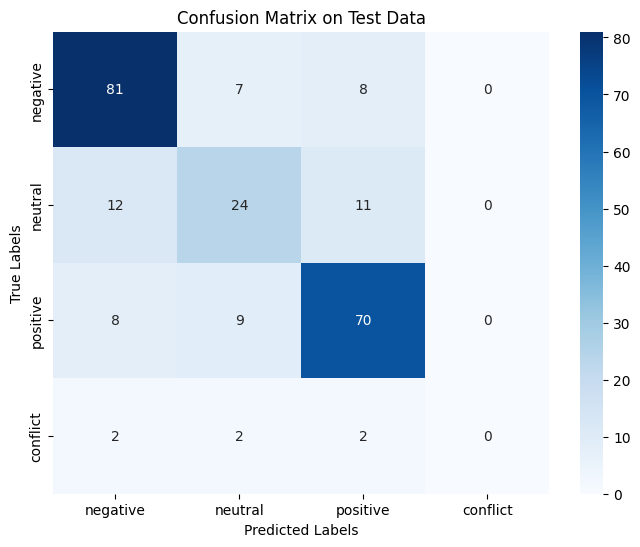


[Phase 3 - C] Extracting 5 Misclassified Examples for Error Analysis:

--- Error #1 ---
Sentence: If you want a little more custom ability, drop a few bucks and upgrade to one of the more robust versions of Win 7 and grab a 2GB stick of memory to spice it all up a bit more.
Aspect:   2GB stick of memory
True:     POSITIVE
Predicted:NEUTRAL

--- Error #2 ---
Sentence: also you may need to charge it once a day, if for medium use every thing fast and easy with mac  the size and look is the most feature that attracted me to it.
Aspect:   charge
True:     NEUTRAL
Predicted:POSITIVE

--- Error #3 ---
Sentence: Seems to slow down occassionally but can run many applications (ie Internet tabs, programs, etc) simultaneously.
Aspect:   programs
True:     NEUTRAL
Predicted:POSITIVE

--- Error #4 ---
Sentence: The battery doesn't last long but I'm sure an upgrade battery would solve that problem.
Aspect:   battery
True:     NEGATIVE
Predicted:POSITIVE

--- Error #5 ---
Sentence: although its windo

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print(f"Total test samples after merging: {len(test_df)}")

test_df['label'] = test_df['polarity'].map(label_map)
test_df = test_df.dropna(subset=['label'])
test_df['label'] = test_df['label'].astype(int)

test_dataset = ABSADataset(test_df, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=32)

model = model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['negative', 'neutral', 'positive', 'conflict']
print("\n[Phase 3 - A] Classification Report (including Macro-F1):")
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n[Phase 3 - B] Plotting Confusion Matrix...")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix on Test Data')
plt.show()

print("\n[Phase 3 - C] Extracting 5 Misclassified Examples for Error Analysis:")
test_df['predicted'] = all_preds
errors_df = test_df[test_df['label'] != test_df['predicted']]


reverse_label_map = {v: k for k, v in label_map.items()}

count = 0
for index, row in errors_df.head(5).iterrows():
    count += 1
    true_label_text = reverse_label_map[row['label']]
    pred_label_text = reverse_label_map[row['predicted']]

    print(f"\n--- Error #{count} ---")
    print(f"Sentence: {row['Sentence']}")
    print(f"Aspect:   {row['Aspect Term']}")
    print(f"True:     {true_label_text.upper()}")
    print(f"Predicted:{pred_label_text.upper()}")

total_errors = len(errors_df)
total_samples = len(test_df)
print(f"❌ Total misclassified examples: {total_errors} out of {total_samples}")
print(f"✅ Accuracy based on errors: {((total_samples - total_errors) / total_samples) * 100:.2f}%\n")